# Visualize trained deep-MPN weights across learning rules

Reload the deep-MPN (`dmpn`) networks saved by `train_mpn.py` (one seed, each
learning rule) and compare the three learned **weight matrices `W`** (not the
data-dependent modulation `M`):

| Component | Parameter | Shape | Role |
|---|---|---|---|
| **Input layer** | `W_initial_linear.weight` | `(n_embed, n_input)` | raw input → embedding |
| **Modulation-layer W** | `mp_layers[0].W` | `(n_hidden, n_embed)` | plastic MP weight (base of `W + W⊙M`) |
| **Output layer** | `W_output` | `(n_output, n_hidden)` | hidden → readout |

This is the RNN-comparable architecture (input → hidden → output), with the
plastic `M` playing the recurrence role. Set `SEED` / `RULES` below to match a
completed `train_mpn.py` run (checkpoints are assumed to be `dmpn`).

In [1]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt

import _bootstrap  # noqa: F401  -- prepends ../core + ../scripts to sys.path
import mpn_tasks
import mpn
import train_mpn as tm      # ONLY for load_net (checkpoint-driven; ignores tm globals)

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

# Rule display labels/colors kept LOCAL so this notebook does not depend on train_mpn globals.
RULE_LABEL = {"bptt": "BPTT", "local_diag_rflo": "diagonal RFLO",
              "local_exact_rowlocal": "exact row-local", "local_direct": "direct"}
RULE_COLOR = {"bptt": "#1f77b4", "local_diag_rflo": "#d62728",
              "local_exact_rowlocal": "#2ca02c", "local_direct": "#9467bd"}

## 1. Choose the run to load (by checkpoint name)

In [2]:
# --- run selection: point directly at saved checkpoints ---
# CKPT_STEM is the checkpoint filename up to (and INCLUDING) the trailing "_" that
# precedes "{rule}_seed{SEED}.pt". Copy it straight from a saved checkpoint name, e.g.
#   dmpn_contextdelaydm1_h200-200_b128_n5000_lr1e-03_direct_fa_eta1.00_lam0.99_
# Loaded per rule:  {CKPT_DIR}/{CKPT_STEM}{rule}_seed{SEED}.pt
# The net AND (below) the task config come from the checkpoints themselves — nothing
# is regenerated from train_mpn's globals.
CKPT_DIR  = tm.CKPT_DIR    # default <root>/checkpoints; set to any path you like
CKPT_STEM = "dmpn_contextdelaydm1_h200-200_b128_n5000_lr1e-03_direct_fa_eta1.00_lam0.99_"
SEED      = 44             # the seed suffix on the checkpoint files
RULES     = ["bptt", "local_diag_rflo", "local_direct"]
DEVICE    = torch.device("cpu")

nets, ckpts = {}, {}
for rule in RULES:
    path = os.path.join(CKPT_DIR, f"{CKPT_STEM}{rule}_seed{SEED}.pt")
    ckpts[rule] = torch.load(path, map_location=DEVICE, weights_only=False)
    nets[rule]  = tm.load_net(path, device=DEVICE)   # rebuilds the net from ckpt net_params
    print(f"{rule:20} <- {os.path.basename(path)}")

any_net = nets[RULES[0]]
any_ck  = ckpts[RULES[0]]
RULESET = any_ck.get("ruleset") or any_ck.get("net_params", {}).get("ruleset", "?")
n_input  = any_net.n_input
n_hidden = any_net.n_hidden
n_output = any_net.n_output
print(f"\nruleset={RULESET}  n_input={n_input}  n_hidden={n_hidden}  n_output={n_output}")

bptt                 <- dmpn_contextdelaydm1_h200-200_b128_n5000_lr1e-03_direct_fa_eta1.00_lam0.99_bptt_seed44.pt
local_diag_rflo      <- dmpn_contextdelaydm1_h200-200_b128_n5000_lr1e-03_direct_fa_eta1.00_lam0.99_local_diag_rflo_seed44.pt
local_direct         <- dmpn_contextdelaydm1_h200-200_b128_n5000_lr1e-03_direct_fa_eta1.00_lam0.99_local_direct_seed44.pt

ruleset=?  n_input=6  n_hidden=200  n_output=3


## 2. Extract the trained weight matrices

We visualize the learned **weights `W`** only (not the data-dependent modulation
`M`). For `dmpn` there are three: `W_initial_linear.weight` (input→embedding),
`mp_layers[0].W` (the plastic MP-layer weight), and `W_output` (readout).

In [3]:
# Weight matrices per rule, adaptive to ANY number of MP layers. comp[rule] holds
# W_in (input embedding), one W_mp{k} per MP layer k (0-based), and W_out (readout).
# `cols` is the ordered (key, title) list every downstream figure iterates over, so
# a deep MP stack shows each modulation layer's static weight SEPARATELY.
n_layers = len(any_net.mp_layers)

cols = [("W_in", "input layer  (embed×input)")]
for k in range(n_layers):
    cols.append((f"W_mp{k}", f"modulation layer {k}  W  (post×pre)"))
cols.append(("W_out", "output layer  W_out  (output×hidden)"))

comp = {}   # comp[rule] = {'W_in', 'W_mp0', 'W_mp1', ..., 'W_out'}
for rule, net in nets.items():
    d = {"W_in": net.W_initial_linear.weight.detach().cpu().numpy()}   # (n_embed, n_input)
    for k, mp in enumerate(net.mp_layers):
        d[f"W_mp{k}"] = mp.W.detach().cpu().numpy()                    # (post, pre)
    d["W_out"] = net.W_output.detach().cpu().numpy()                   # (n_output, n_hidden)
    comp[rule] = d
    mp_mags = "  ".join(f"|W_mp{k}| {np.abs(d[f'W_mp{k}']).mean():.3e}" for k in range(n_layers))
    print(f"{rule:20} |W_in| {np.abs(d['W_in']).mean():.3e}  {mp_mags}  "
          f"|W_out| {np.abs(d['W_out']).mean():.3e}")

bptt                 |W_in| 9.298e-02  |W_mp0| 6.417e-02  |W_mp1| 6.390e-02  |W_out| 6.703e-02
local_diag_rflo      |W_in| 8.695e-02  |W_mp0| 6.246e-02  |W_mp1| 6.232e-02  |W_out| 8.353e-02
local_direct         |W_in| 1.731e-01  |W_mp0| 8.253e-02  |W_mp1| 6.680e-02  |W_out| 3.037e-02


## 3. Weight heatmaps — one row per learning rule

Columns: **input layer** `W_initial_linear`, **modulation-layer** `mp_layers[0].W`,
and **output layer** `W_output`. A shared symmetric color scale per column makes
rules directly comparable.

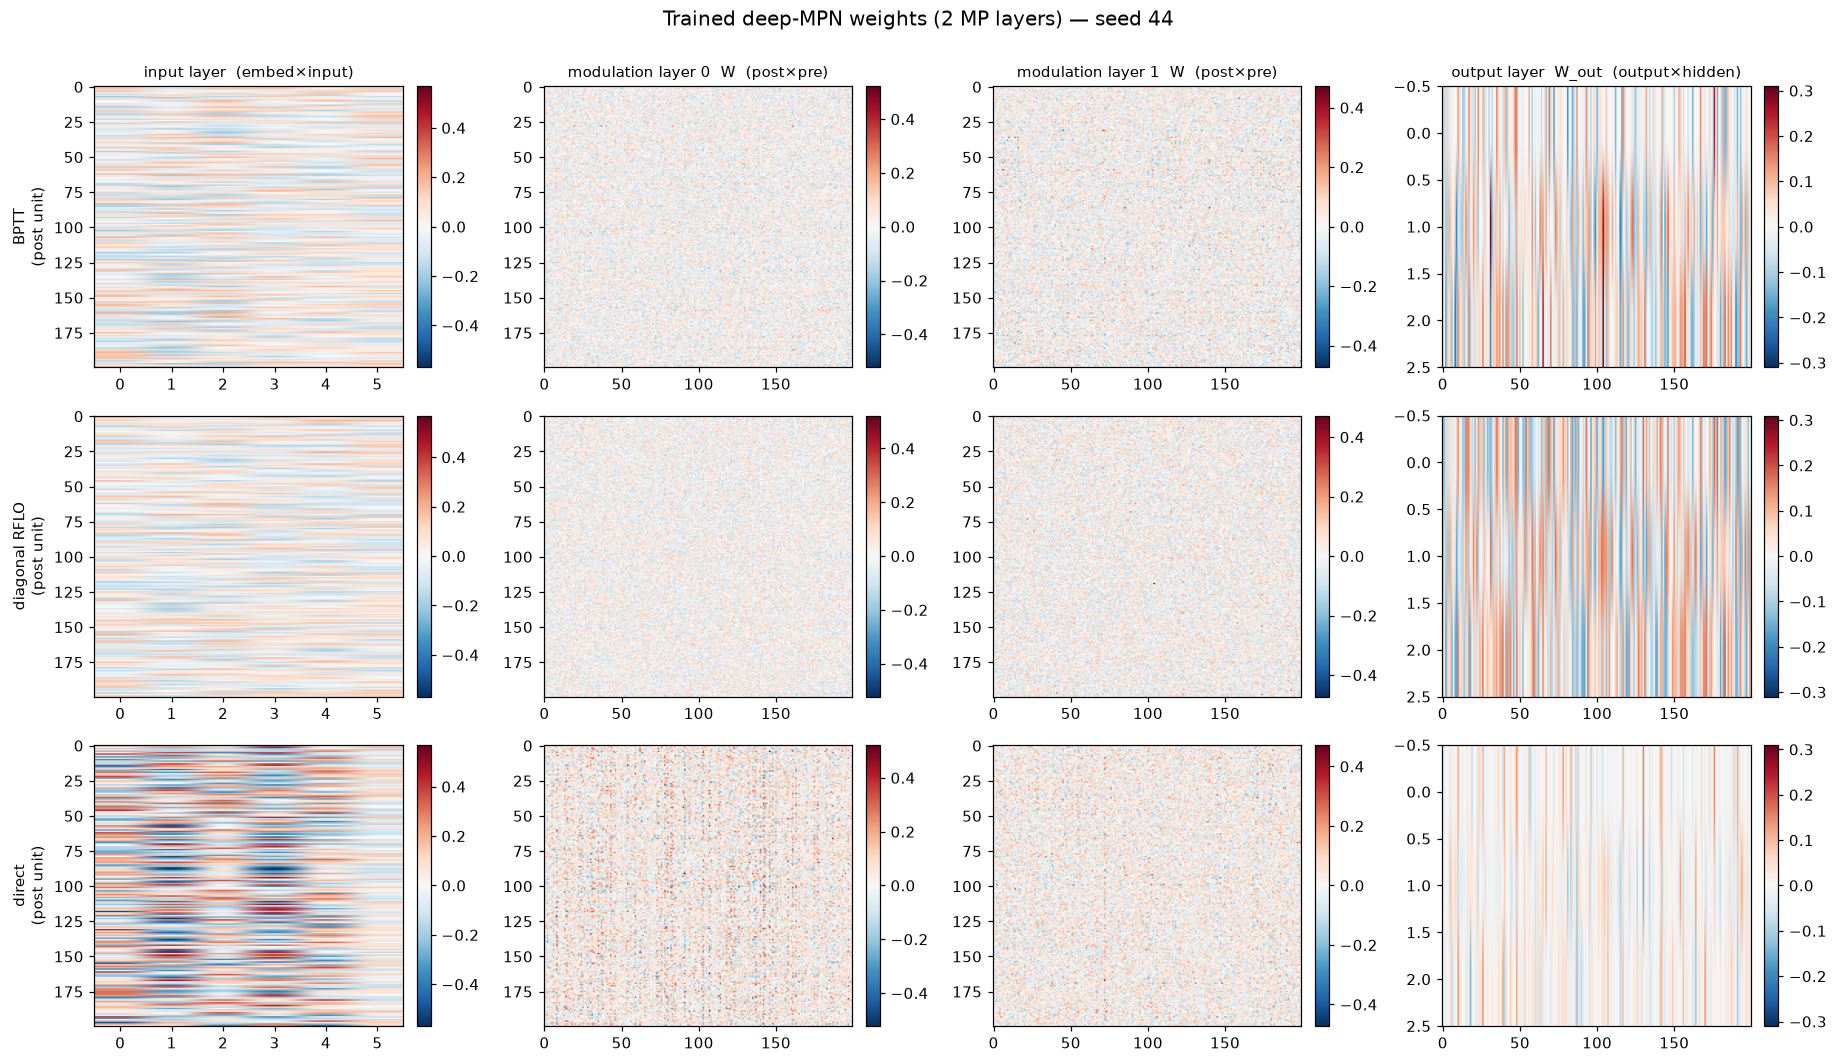

In [4]:
# Shared symmetric vlim per column (comparable across rules).
vlim = {key: max(np.abs(comp[r][key]).max() for r in RULES) for key, _ in cols}

nrows, ncols = len(RULES), len(cols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.2 * nrows),
                         squeeze=False)
for i, rule in enumerate(RULES):
    for j, (key, title) in enumerate(cols):
        ax = axes[i][j]
        v = vlim[key]
        im = ax.imshow(comp[rule][key], aspect="auto", cmap="RdBu_r", vmin=-v, vmax=v)
        if i == 0:
            ax.set_title(title, fontsize=10)
        if j == 0:
            ax.set_ylabel(f"{RULE_LABEL.get(rule, rule)}\n(post unit)", fontsize=10)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle(f"Trained deep-MPN weights ({n_layers} MP layer"
             f"{'s' if n_layers != 1 else ''}) — seed {SEED}", y=1.002, fontsize=13)
fig.tight_layout()
plt.show()

## 4. Weight distributions (overlaid histograms)

For each weight matrix, overlay the flattened weight distributions of
the learning rules on shared bins. This shows how the *shape/spread* of
the learned weights differs across rules (e.g. whether a local rule
learns systematically larger / more sparse weights than BPTT), which the
heatmaps above don't make quantitative.

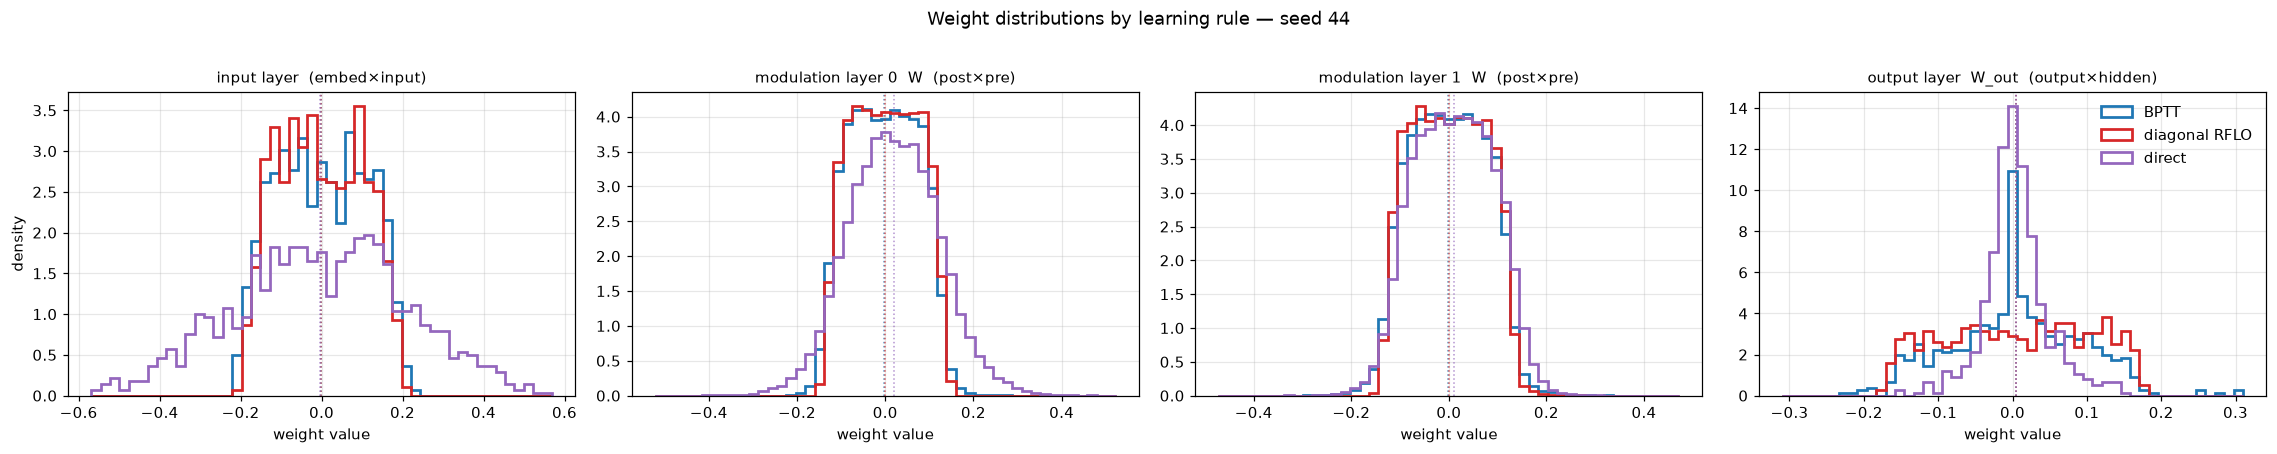

component  rule                  mean       std    max|w|
W_in       BPTT             -9.581e-04 1.079e-01 2.267e-01
W_in       diagonal RFLO    -2.367e-03 1.007e-01 2.028e-01
W_in       direct           -2.713e-03 2.124e-01 5.691e-01
W_mp0      BPTT             -2.974e-03 7.528e-02 3.121e-01
W_mp0      diagonal RFLO    2.518e-04 7.265e-02 1.620e-01
W_mp0      direct           1.882e-02 1.016e-01 5.224e-01
W_mp1      BPTT             -8.179e-04 7.586e-02 3.718e-01
W_mp1      diagonal RFLO    4.960e-04 7.268e-02 4.724e-01
W_mp1      direct           1.022e-02 7.966e-02 3.813e-01
W_out      BPTT             4.521e-03 8.645e-02 3.100e-01
W_out      diagonal RFLO    5.262e-03 9.642e-02 1.813e-01
W_out      direct           4.412e-03 4.262e-02 1.540e-01


In [5]:
fig, axes = plt.subplots(1, len(cols), figsize=(5.2 * len(cols), 4.0),
                         squeeze=False)
for j, (key, title) in enumerate(cols):
    ax = axes[0][j]
    # Shared symmetric bins across rules for a fair overlay.
    vmax = max(np.abs(comp[r][key]).max() for r in RULES)
    bins = np.linspace(-vmax, vmax, 50)
    for rule in RULES:
        w = comp[rule][key].ravel()
        ax.hist(w, bins=bins, density=True, histtype='step', linewidth=1.8,
                color=RULE_COLOR.get(rule), label=RULE_LABEL.get(rule, rule))
        ax.axvline(w.mean(), color=RULE_COLOR.get(rule), ls=':', lw=1, alpha=0.7)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('weight value')
    ax.grid(alpha=0.3)
axes[0][0].set_ylabel('density')
axes[0][-1].legend(frameon=False)
fig.suptitle(f'Weight distributions by learning rule — seed {SEED}', y=1.02)
fig.tight_layout()
plt.show()

# Per-rule distribution statistics (mean, std, max|w|) for every component.
print(f"{'component':10} {'rule':16} {'mean':>9} {'std':>9} {'max|w|':>9}")
for key, _ in cols:
    for rule in RULES:
        w = comp[rule][key].ravel()
        print(f'{key:10} {RULE_LABEL.get(rule, rule):16} '
              f'{w.mean():>9.3e} {w.std():>9.3e} {np.abs(w).max():>9.3e}')

## 5. Modulation (M) dynamics — how much each rule uses plasticity

The weights above are static; the MPN's computation lives in the **data-dependent
modulation `M`**, evolved over each trial by the Hebbian update
`M_t = λ M_{t-1} + η · hiddenᵀ x`. `M` is precisely the quantity the local rules
approximate: **diagonal RFLO** discounts its history, and **direct** stops the
gradient through it entirely. So the sharpest question about the learning modes is
functional: *does a rule learn to rely on plasticity, or collapse toward a static
network?*

We roll each rule's trained net over the **same** held-out trials and track two
things vs time:

- **RMS(M)** — the typical magnitude of the modulation entries `|M_ij|`.
- **dynamic fraction** `‖W⊙M‖ / ‖W‖` — the share of the effective weight
  `W + W⊙M` that is dynamic (from plasticity) rather than static.

A rule that credits M-history well (BPTT) may drive larger, more structured `M`
that builds through the delay; a rule that discounts it may keep `M` small and
solve the task more statically. The top panel shows the mean input drive so the
`M` traces can be read against the trial's fixation / stimulus / delay / response
epochs.

held-out ?: inputs (64, 136, 6)  (B=64, T=136)  MP layers=2


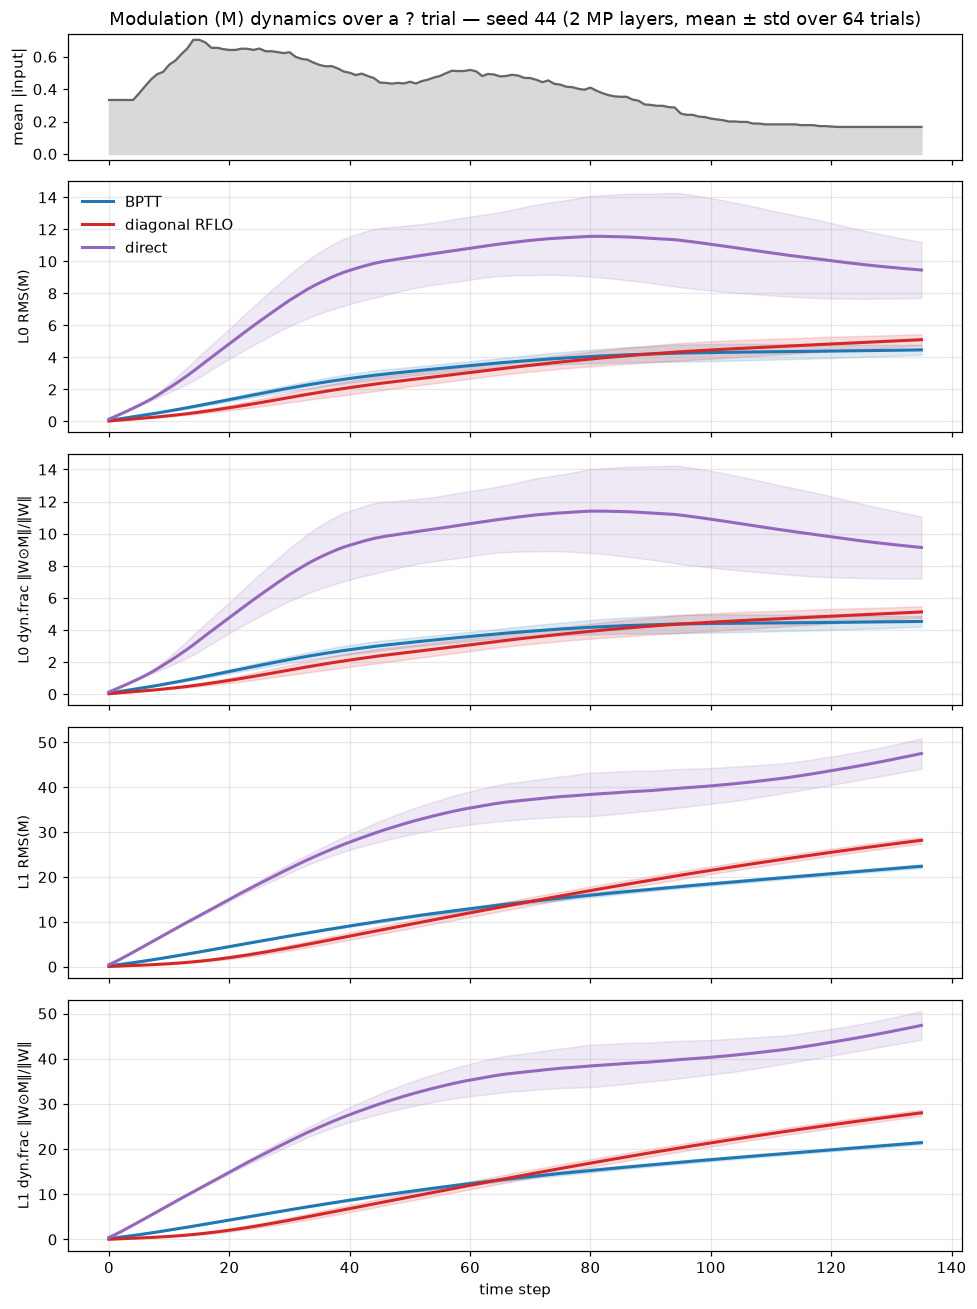

layer  rule              peak RMS(M)  final RMS(M)  peak dyn.frac  final dyn.frac
L0     BPTT                4.473e+00     4.473e+00          4.537           4.537
L0     diagonal RFLO       5.108e+00     5.108e+00          5.127           5.127
L0     direct              1.157e+01     9.460e+00         11.409           9.143
L1     BPTT                2.239e+01     2.239e+01         21.431          21.431
L1     diagonal RFLO       2.818e+01     2.818e+01         28.023          28.023
L1     direct              4.752e+01     4.752e+01         47.377          47.377


In [6]:
# --- Roll out each rule's net on the SAME held-out trials, logging M_t PER LAYER ---
# The learned static weights (above) are only half the story: the MPN solves the
# task with the DATA-DEPENDENT modulation M, and M is exactly the term the local
# rules approximate (diagonal RFLO discounts M-history; 'direct' stops the gradient
# through it entirely). For a DEEP MP stack we log M for EVERY layer separately and
# report, per layer, how much plasticity each rule uses: RMS(M_t) and the dynamic
# fraction ‖W⊙M_t‖ / ‖W‖ of the effective weight.
import tasks

DTYPE = torch.float32
N_TRIALS = 64          # held-out trials to average over (kept modest for speed)

# Draw a held-out batch from the checkpoint's OWN task params (saved at train time),
# so no matching train_mpn config is needed. Older checkpoints that predate
# task_params storage fall back to tm.build_params() with a warning.
if "task_params" in any_ck:
    _tp  = any_ck["task_params"]     # already through init_params (has hp/prefs/rules)
    _trp = dict(any_ck.get("train_params", {}))
else:
    print("WARNING: checkpoint has no stored task_params (old format) -- falling back to "
          "tm.build_params(); its config must match the trained run.")
    _task = tasks.make_task(RULESET)
    _tp, _trp, _np = tm.build_params()
    _tp, _trp, _np = _task.init_params(_tp, _trp, _np)
    _trp = dict(_trp)
task = tasks.make_task(RULESET)
_trp["valid_n_batch"] = N_TRIALS
inputs, labels, mask = task.valid_batch(_tp, _trp, DEVICE, DTYPE)
B, T, _ = inputs.shape
print(f"held-out {RULESET}: inputs {tuple(inputs.shape)}  (B={B}, T={T})  "
      f"MP layers={n_layers}")


@torch.no_grad()
def rollout_modulation(net, inputs):
    """Step the net over the trial; per MP LAYER record, per sample & time:
      m_rms[k]   = RMS(M_t^{(k)})              — typical |M_ij|, modulation size
      dynfrac[k] = ‖W^{(k)}⊙M_t^{(k)}‖_F / ‖W^{(k)}‖_F   — dynamic share of W_eff
    network_step runs the forward (using M_{t-1}) then updates every layer's M, so
    after the call net.mp_layers[k].M is M_t^{(k)}. Returns (m_rms, dynfrac), each a
    list over layers of (B, T) arrays."""
    B, T, _ = inputs.shape
    net.reset_state(B=B)
    L_ = len(net.mp_layers)
    Ws   = [mp.W for mp in net.mp_layers]
    Wnrm = [W.norm().clamp_min(1e-12) for W in Ws]
    nel  = [mp.M_init.numel() for mp in net.mp_layers]
    m_rms   = [np.zeros((B, T)) for _ in range(L_)]
    dynfrac = [np.zeros((B, T)) for _ in range(L_)]
    for t in range(T):
        net.network_step(inputs[:, t, :], seq_idx=t)
        for k, mp in enumerate(net.mp_layers):
            M = mp.M                                             # (B, post, pre) = M_t
            m_rms[k][:, t]   = (M.reshape(B, -1).norm(dim=1) / np.sqrt(nel[k])).cpu().numpy()
            WM = (Ws[k].unsqueeze(0) * M).reshape(B, -1).norm(dim=1)
            dynfrac[k][:, t] = (WM / Wnrm[k]).cpu().numpy()
    return m_rms, dynfrac


mod = {rule: rollout_modulation(net, inputs) for rule, net in nets.items()}

# --- Figure: task drive + per-layer RMS(M) + per-layer dynamic fraction ---
# Rows: 1 (input drive) + 2 per MP layer (RMS(M) then dyn.frac), so each modulation
# layer is shown separately. Curves = mean ± std across trials, one color per rule.
tsteps = np.arange(T)
ctx = inputs.abs().mean(dim=(0, 2)).cpu().numpy()     # mean |input| over trials+channels

nrows = 1 + 2 * n_layers
fig, axes = plt.subplots(nrows, 1, figsize=(9, 2.4 * nrows), sharex=True,
                         gridspec_kw={"height_ratios": [1] + [2] * (2 * n_layers)},
                         squeeze=False)
axes = axes[:, 0]
axes[0].plot(tsteps, ctx, color="0.4", lw=1.5)
axes[0].fill_between(tsteps, 0, ctx, color="0.85")
axes[0].set_ylabel("mean |input|")
axes[0].set_title(f"Modulation (M) dynamics over a {RULESET} trial — seed {SEED} "
                  f"({n_layers} MP layer{'s' if n_layers != 1 else ''}, "
                  f"mean ± std over {B} trials)")

for k in range(n_layers):
    ax_rms = axes[1 + 2 * k]
    ax_dyn = axes[2 + 2 * k]
    for ax, sel, ylab in [(ax_rms, 0, f"L{k} RMS(M)"),
                          (ax_dyn, 1, f"L{k} dyn.frac ‖W⊙M‖/‖W‖")]:
        for rule in RULES:
            arr = mod[rule][sel][k]                 # (B, T)
            mean, std = arr.mean(0), arr.std(0)
            c = RULE_COLOR.get(rule)
            ax.plot(tsteps, mean, color=c, lw=2, label=RULE_LABEL.get(rule, rule))
            ax.fill_between(tsteps, mean - std, mean + std, color=c, alpha=0.15)
        ax.set_ylabel(ylab, fontsize=9)
        ax.grid(alpha=0.3)
axes[1].legend(frameon=False, loc="upper left")   # legend on the first M panel
axes[-1].set_xlabel("time step")
fig.tight_layout()
plt.show()

# --- Summary: how much plasticity each rule uses, PER LAYER ---
print(f"{'layer':6} {'rule':16} {'peak RMS(M)':>12} {'final RMS(M)':>13} "
      f"{'peak dyn.frac':>14} {'final dyn.frac':>15}")
for k in range(n_layers):
    for rule in RULES:
        mm = mod[rule][0][k].mean(0); dd = mod[rule][1][k].mean(0)   # mean over trials → (T,)
        print(f"L{k:<5} {RULE_LABEL.get(rule, rule):16} {mm.max():>12.3e} {mm[-1]:>13.3e} "
              f"{dd.max():>14.3f} {dd[-1]:>15.3f}")